# **Tutorial: Computation in neuroscience & AI: a dynamical systems perspective**

Playground for $\textrm{RNNs}$

In [ ]:
# Import common packages
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

### Defining a recurrent neural network


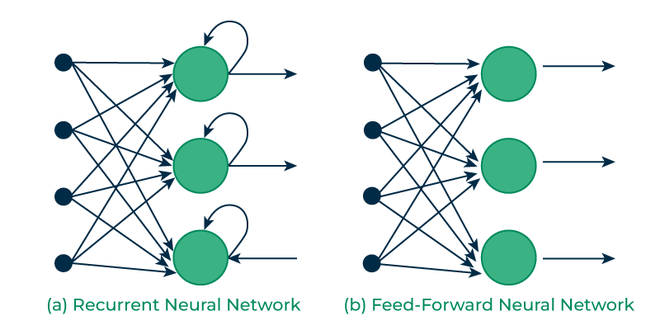

image from https://www.geeksforgeeks.org/machine-learning/introduction-to-recurrent-neural-network/

LSTM: A typical recurrent network in machine learning.
Define number of input units, number of hidden units, and number of layers

In [ ]:
# Make an LSTM, imported from the torch.nn library
#input_size is the dimension of inputs, hidden_size is the number of hidden neurons
rnn = nn.LSTM(input_size=10, hidden_size=20, num_layers=2)

# Generate some mock inputs
input = torch.randn(5, 3, 10)  # (Sequence Length, Batch Size, Input Size)
output, (hn, cn) = rnn(input)

print('Output shape is (SeqLen, BatchSize, HiddenSize):', output.shape)

Output shape is (SeqLen, BatchSize, HiddenSize): torch.Size([5, 3, 20])


In general, recurrent neural networks transform sequence to sequence. Other network architectures, such as MultiHeadAttetion as used in
Transformers, can also be thought of as sequence to sequence.

In the context of cognitive neuroscience, the sequence is usually a time series of task input or output.

In [ ]:
input = torch.randn(5, 3, 10)  # (Sequence Length, Batch Size, Input Size)

lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=2)
output, _ = lstm(input)
print('Output shape is (SeqLen, BatchSize, Dimension):', output.shape)

rnn = nn.RNN(input_size=10, hidden_size=20, num_layers=2)
output, _ = rnn(input)
print('Output shape is (SeqLen, BatchSize, Dimension):', output.shape)

gru = nn.GRU(input_size=10, hidden_size=20, num_layers=2)
output, _ = gru(input)
print('Output shape is (SeqLen, BatchSize, Dimension):', output.shape)

mha = nn.MultiheadAttention(embed_dim=10, num_heads=1)
output, _ = mha(query=input, key=input, value=input)
print('Output shape is (SeqLen, BatchSize, Dimension):', output.shape)

Output shape is (SeqLen, BatchSize, Dimension): torch.Size([5, 3, 20])
Output shape is (SeqLen, BatchSize, Dimension): torch.Size([5, 3, 20])
Output shape is (SeqLen, BatchSize, Dimension): torch.Size([5, 3, 20])
Output shape is (SeqLen, BatchSize, Dimension): torch.Size([5, 3, 10])


$\textrm{RNNs}$ are a type of neural network for sequence data.


**Input**: a sequence $x_1, x_2, ..., x_T$.

$\textrm{RNNs}$ transforms a sequence of
 inputs $\{x_i\}_i$ into a sequence of **outputs** $\{y_i\}_i$ and processes the sequential data $x_i$ by using recurrent connections (i.e., feedback loops) where output of a neuron at one time step is fed back as input to the network at the next time step.

\begin{align}
\textbf{h}_{t+1} = \textbf{w}_h \cdot \textbf{h}_t + \textbf{w}_i \cdot \textbf{x}_t
\end{align}

where $\textbf{h}_{t+1}$ is the hidden state at time $t$ influenced by $\textbf{x}_t$ and $\textbf{h}_t$.

**Output $\textbf{y}_t$** is given by:

\begin{align}
\textbf{y}_{t} = \textbf{w}_o \cdot \textbf{h}_t
\end{align}

This is a basic, linear $\textbf{RNN}$.

In multiple dimensions, $\textbf{x}_t \in \mathbb{R}^n$, $\textbf{h}_t \in \mathbb{R}^k$, $\textbf{y}_t \in \mathbb{R}^m$, and $\textbf{W}_i \in \mathbb{R}^{n \times k}, \textbf{W}_h \in \mathbb{R}^{k \times k}, \textbf{W}_o \in \mathbb{R}^{k \times m}$ are matrices to transform the input, hidden layer, and output, respectively.


\begin{align}
\begin{cases}
\textbf{h}_{t+1} &= \textbf{W}_i \textbf{x}_t + \textbf{W}_h \textbf{h}_t \\
\textbf{y}_{t+1} &= \textbf{W}_o \textbf{h}_t
\end{cases}
\end{align}


$\Rightarrow \textrm{RNNs}$ can capture temporal dependencies and patterns within sequences, especially if we add non-linearities to the formulas above.

.

Another way to describe an RNN is in a continuous-time setting, where the hidden state evolves according to a differential equation, and the trajectory is obtained by discretizing this equation in time. A common continuous-time formulation of an RNN is:

$$\tau \frac{dh(t)}{dt} = -h(t) + W_{hh}\,\phi(h(t)) + W_{ih}\,i(t) + b$$

where $h(t)$ is the hidden state, $\textbf{i}(t)$ is the input, $\textbf{W}_{hh}$, and $\textbf{W}_{ih}$ are recurrent and input weight matrices, $\textbf{b}$ is a bias term, $\tau$ is a time constant, and $\phi(⋅)$ is a nonlinear activation function such as $\textrm{tanh}$.

To simulate this system on a computer, the continuous dynamics are typically discretized using a numerical integration scheme such as Euler’s method:

$$\textbf{h}_{t+1} = \textbf{h}_t + \frac{\Delta t}{\tau}\left(-\textbf{h}_t + \textbf{W}_{hh}\,\phi(\textbf{h}_t) + \textbf{W}_{ih}\,\textbf{i}_t + \textbf{b}\right).$$

This discrete update closely resembles standard RNN equations, but makes explicit that the dynamics arise from an underlying continuous-time system.

In [ ]:
class CTRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dt=1.0, tau=100.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.tau = tau
        self.alpha = dt / tau

        self.W_in = nn.Linear(input_size, hidden_size, bias=True)
        self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bias = nn.Parameter(torch.zeros(hidden_size))

        self.nonlinearity = torch.tanh

    def init_hidden(self, batch_size, device):
        return torch.zeros(batch_size, self.hidden_size, device=device)

    def recurrence(self, u_t, h):
        r = self.nonlinearity(h)
        dh = -h + self.W_rec(r) + self.W_in(u_t) + self.bias
        h_new = h + self.alpha * dh
        return h_new

    def forward(self, u, h0=None):
        # u: (seq_len, batch, input_size)
        seq_len, batch_size, _ = u.shape
        device = u.device

        if h0 is None:
            h = self.init_hidden(batch_size, device)
        else:
            h = h0

        hs = []
        rs = []

        for t in range(seq_len):
            h = self.recurrence(u[t], h)
            r = self.nonlinearity(h)
            hs.append(h)
            rs.append(r)

        hs = torch.stack(hs, dim=0)
        rs = torch.stack(rs, dim=0)

        return rs, hs


class RNNNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dt=1.0, tau=100.0):
        super().__init__()
        self.rnn = CTRNN(input_size, hidden_size, dt=dt, tau=tau)
        self.readout = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        r, h = self.rnn(x, h0)
        y = self.readout(r)
        return y, r, h

In [ ]:
rnn = RNNNet(10, 5, 2)
rnn

RNNNet(
  (rnn): CTRNN(
    (W_in): Linear(in_features=10, out_features=5, bias=True)
    (W_rec): Linear(in_features=5, out_features=5, bias=False)
  )
  (readout): Linear(in_features=5, out_features=2, bias=True)
)

In [ ]:
input = torch.randn((5,1,10)) #batch = 1, seq_len = 5, input_size = 10
output, r_arr, h_arr = rnn(input)
output.shape, r_arr.shape, h_arr.shape

(torch.Size([5, 1, 2]), torch.Size([5, 1, 5]), torch.Size([5, 1, 5]))

**The real differences in dynamics between discrete RNN and continuous RNN**

1. Natural time scale


*   Continuous RNNs include an explicit time constant $\tau$
*   Controls how fast hidden states evolve.
*   Gives the model an inherent notion of physical time.

Standard RNNs don't have this — time is just iteration count.

2. Stability criteria are different

<table>
  <tr>
    <th>Model type</th>
    <th>Time</th>
    <th>Dynamics</th>
    <th>Stabilty condition</th>
  </tr>
  <tr>
    <td>Discrete RNN</td>
    <td>Step-based</td>
    <td style="width:100%;"> Map \( h_{t+1} = f(h_t) \) </td>
    <td>\(|Re(\lambda)| < 1\)</td>
  </tr>
  <tr>
    <td>Continuous RNN</td>
    <td>Continuous</td>
    <td style="width:100%;">\(\tau \frac{dh}{dt} = F(h)\)</td>
    <td>\(Re(\lambda) < 0\)</td>
  </tr>

</table>

This changes how:

*  attractors
*  line attractors
*  oscillations

appear and are interpreted.

3. Continuous RNNs connect naturally to neuroscience

They behave like:

*  leaky integrators
*  firing-rate
*  neuronal models

That's why papers like Mante, Sussillo et. al. neural computation work use them: they let you talk about flows, manifolds, attractors, and line attractors in a principled dynamical systems way.

4. Discretization blurs the distinction

If you discretize a continuous RNN with Euler:

$$h_{t+1}=h_t+ \frac{dt}{\tau} F(h_t,i_t)$$

you essentially recover a “normal” RNN — but now:

you control stability by $\Delta t/\tau$ and the dynamics are constrained by the underlying continuous system.

.

Simplest RNN: $\tau \frac{dh_i}{dt} = -h_i$ for all i units



In [ ]:
class simplest_RNN(nn.Module):
    def __init__(self, input_size, dt=1.0, tau=100.0, T_int=50):
        super().__init__()
        self.tau = tau
        self.alpha = dt / tau

        self.T_int = T_int
    def forward(self, h):

        hs = []

        for t in range(self.T_int):
            h = h + self.alpha * (-h)
            hs.append(h)

        hs = torch.stack(hs, dim=0)

        return hs.T.squeeze()

In [ ]:
rnn_exp_decay = simplest_RNN(3, dt=1, tau=5)

input = torch.randn(1, 1, 3)
output = rnn_exp_decay(input)

output.shape

/tmp/ipython-input-1051111473.py:18: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  return hs.T.squeeze()


torch.Size([3, 50])

Text(0, 0.5, 'feature 2')

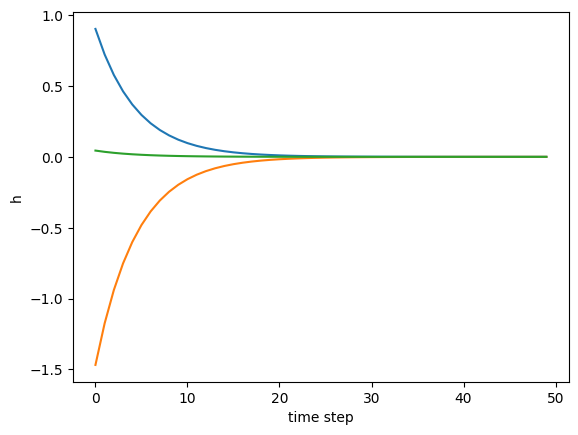

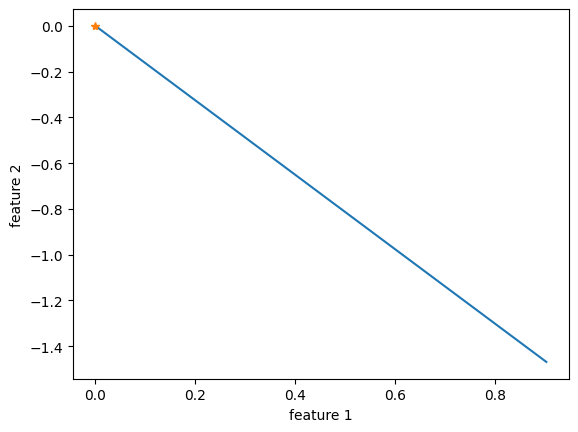

In [ ]:
plt.figure()
plt.plot(output[0,:])
plt.plot(output[1,:])
plt.plot(output[2,:])
plt.xlabel("time step")
plt.ylabel("h")

plt.figure()
plt.plot(output[0,:], output[1,:])
plt.plot([0], [0], "*")
plt.xlabel("feature 1")
plt.ylabel("feature 2")

Text(0, 0.5, 'h')

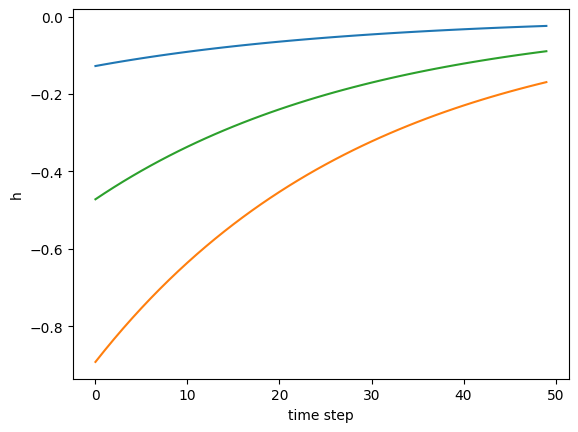

In [ ]:
#this can decay slower if we change (increase) tau
rnn_exp_decay = simplest_RNN(3, dt=1, tau=30)

input = torch.randn(1, 1, 3)
output = rnn_exp_decay(input)

plt.figure()
plt.plot(output[0,:])
plt.plot(output[1,:])
plt.plot(output[2,:])
plt.xlabel("time step")
plt.ylabel("h")

These RNNs have very simple boring behavior -- decay to 0!

Simplest RNN: $\tau \frac{dh_i}{dt} = -h_i + I_i$ for all i units


In [ ]:
class simple_RNN_with_input(nn.Module):
    def __init__(self, input_size, dt=1.0, tau=100.0, T_int=50):
        super().__init__()
        self.tau = tau
        self.alpha = dt / tau

        self.T_int = T_int

    def forward(self, h, u):

        hs = []

        for t in range(self.T_int):
            h = h + self.alpha * (-h + u[t,:,:])
            hs.append(h)

        hs = torch.stack(hs, dim=0)

        return hs.T.squeeze()

In [ ]:
T_int = 100
rnn_exp_decay = simple_RNN_with_input(3, dt=1, tau=10, T_int = T_int)

#input is noisy signal with mean [2,3,5]
input = torch.tensor([2,3,5]) + 0.5*torch.randn(rnn_exp_decay.T_int, 1, 3) #(T, B, H)
h = torch.randn(1,3) #B, H
output = rnn_exp_decay(h, input) #T,B,H

output.shape

torch.Size([3, 100])

Text(0.5, 1.0, '2D Dynamics with fixed point (and noise)')

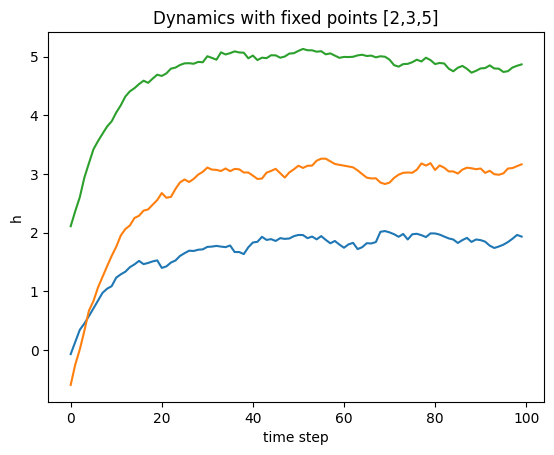

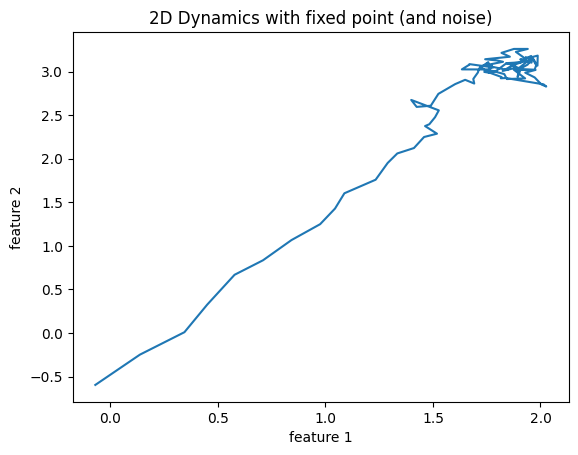

In [ ]:
plt.figure()
plt.plot(output[0,:])
plt.plot(output[1,:])
plt.plot(output[2,:])
plt.xlabel("time step")
plt.ylabel("h")
plt.title("Dynamics with fixed points [2,3,5]")

plt.figure()
plt.plot(output[0,:], output[1,:])
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("2D Dynamics with fixed point (and noise)")

Linear RNN: $\tau \frac{dx_i}{dt} = -x_i + \sum_{j=1}^{N} \textbf{J}_{ij} \cdot x_j$ for all $i$ units

In [ ]:
class linear_RNN(nn.Module):
    def __init__(self, hidden_size, dt=1.0, tau=10.0, T_int=200):
        super().__init__()
        self.hidden_size = hidden_size
        self.alpha = dt / tau
        self.T_int = T_int

        self.J = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.3) #start with smaller weights
        #we'll talk later how the ramping up of weights influences the dynamics

    def forward(self, h0):
        h = h0
        hs = []

        for t in range(self.T_int):
            h = h + self.alpha * (-h + h @ self.J.T)
            hs.append(h)

        hs = torch.stack(hs, dim=0)
        return hs.T.squeeze()

**Example 1: Stable fixed point**

Text(0.5, 1.0, 'Stable fixed point')

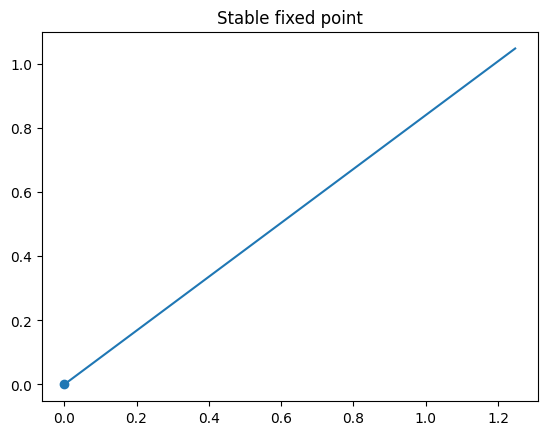

In [ ]:
rnn = linear_RNN(2, tau=10, T_int=200)
rnn.J.data = 0.1 * torch.eye(2)

h0 = torch.randn(1,2)
traj = rnn(h0).detach().numpy()

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.scatter([0],[0])
plt.title("Stable fixed point")

**Example 2: Damped oscillations**

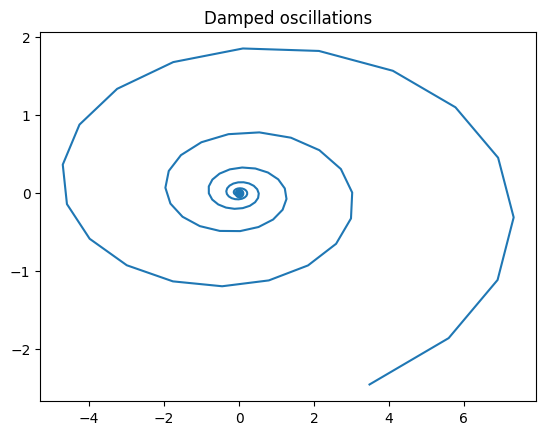

In [ ]:
rnn = linear_RNN(2, tau=10, T_int=300)
rnn.J.data = torch.tensor([[0.0, -10.0],
                           [1.0,  0.0]])

h0 = torch.randn(1,2)
traj = rnn(h0).detach().numpy()

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.title("Damped oscillations")
plt.scatter([0],[0])


**Example 3: Sustained oscillations**

Text(0.5, 1.0, 'Sustained oscillations (approx)')

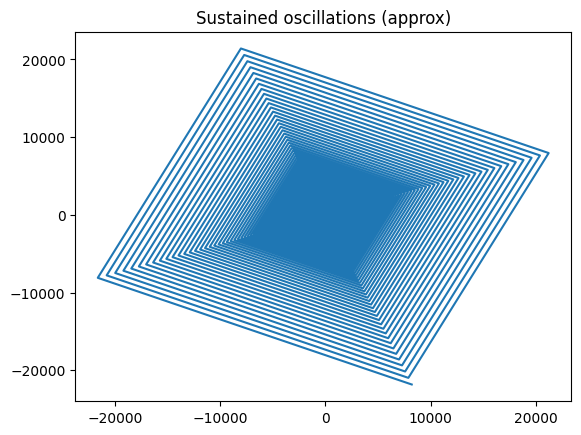

In [ ]:
rnn = linear_RNN(2, tau=1, T_int=1000)
rnn.J.data = torch.tensor([[0.0, -1.0],
                           [1.0,  0.0]])*1.01

h0 = torch.randn(1,2)
traj = rnn(h0).detach().numpy()

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.title("Sustained oscillations (approx)")

**Example 4: Unstable blow-up**

Text(0.5, 1.0, 'Unstable blow-up')

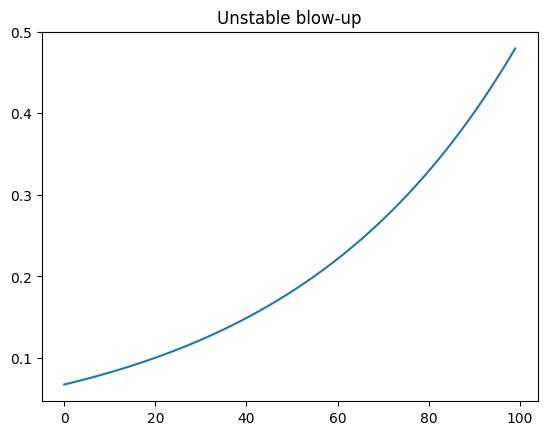

In [ ]:
rnn = linear_RNN(2, tau=10, T_int=100)
rnn.J.data = 1.2 * torch.eye(2)

traj = rnn(torch.randn(1,2)).detach().numpy()

plt.figure()
plt.plot(traj[0,:])
plt.title("Unstable blow-up")

The stability of the dynamics in these RNNs can be inferred analytically by computing all the eigenvalues (i.e. the eigenspectrum)
of the Jacobian matrix corresponding to the dynamics

**Jacobian of the continuous dynamics**

Your dynamics are:

$$ \dot{\textbf{h}} = −\textbf{h} + \textbf{W} \cdot \tanh ⁡(\textbf{h})$$

The Jacobian is:

$$\textbf{J}(h) = −\textbf{I} + \textbf{W} \cdot \textrm{diag} (1 - \tanh^2⁡(\textbf{h}))$$


The eigenspectrum of $\textbf{J}$ determines whether there is stable, unstable or oscillatory dynamics.



*   If there is one or more eigenvalues whose real part > 0 $\Rightarrow$ unstable dynamics
*   If all eigenvalues have real part < 0 $\Rightarrow$ stable fixed point
*   If there are non-zero imaginary parts to the eigenvalues, then there are oscillations

Eigenvectors are important too in better understanding dynamics: they determine the direction in which the trajectory contracts or expands.

**Reminder:** An eigenvector-egenvalue pair $(\textbf{v}, \lambda)$ corresponding to matrix $\textbf{J}$ are a vector-scalar pair such that $\textbf{J} \textbf{v} = \lambda \textbf{v}$

(i.e. $\textbf{v}$ is a direction in space so that the action of $\textbf{J}$ on it expands ($|\lambda| > 1$) or contracts ($|\lambda| < 1$) the vector, or potentially changes its direction (if $\lambda < 0$).

In [ ]:
def jacobian_continuous(h, W):
    """
    h: (N,) tensor
    W: (N,N) weight matrix
    """
    r = torch.tanh(h)
    D = torch.diag(1 - r**2)   # derivative of tanh
    I = torch.eye(W.shape[0])
    J = -I + W @ D
    return J

In [ ]:
def plot_eigs(J, title="Eigenvalue spectrum"):
    eigvals = torch.linalg.eigvals(J).detach().cpu().numpy()

    plt.figure()
    plt.scatter(eigvals.real, eigvals.imag)
    plt.axhline(0, color='k')
    plt.axvline(0, color='k')
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.title(title)
    plt.axis("equal")
    plt.show()

What we are interested actually are the eigenvalues/eigenvectors of the discrete system, since that is the one we are using to compute the dynamics (of course the discrete dynamics is an approximation of the continuous one)

In [ ]:
def jacobian_discrete(J_cont, alpha):
    I = torch.eye(J_cont.shape[0])
    return I + alpha * J_cont

**Exercise**: Try using these functions to plot the eigenspectrum corresponding to the dynamics... and check if the dynamics matches what we expect given the eigenvalues (see the rules above regarding sign of $\lambda$).


Warning: for discrete dynamics the rules of stability are actually a little bit different:


*   If there is one or more eigenvalues are outside the unit circle (i.e. norm > 1) $\Rightarrow$ unstable dynamics
*   If all eigenvalues are inside unit circle (i.e. norm < 1) $\Rightarrow$ stable fixed point
*   Eigenvalues with magnitude $\approx 1$ and a nonzero complex angle produce oscillations or nearly persistent dynamics.




.

**Non-linear RNN is a game-changer**

$$ h_{t+1} = h_t + \frac{dt}{\tau} \cdot (-\textbf{h}_t + \textbf{W} \cdot \phi( \textbf{h}_t))$$
Why? Because it allows us to have richer dynamics, not just going to 0 or blowing up.

In [ ]:
class nonlinear_RNN(nn.Module):
    def __init__(self, hidden_size, dt=1.0, tau=10.0, T_int=300):
        super().__init__()
        self.hidden_size = hidden_size
        self.alpha = dt / tau
        self.T_int = T_int
        self.W = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.5)

    def forward(self, h0):
        h = h0
        hs = []

        for t in range(self.T_int):
            r = torch.tanh(h)
            h = h + self.alpha * (-h + r @ self.W.T)
            hs.append(h)

        hs = torch.stack(hs, dim=0)
        return hs.T.squeeze()

**Example 5: Stable fixed point**

Text(0.5, 1.0, 'Nonlinear: stable fixed point')

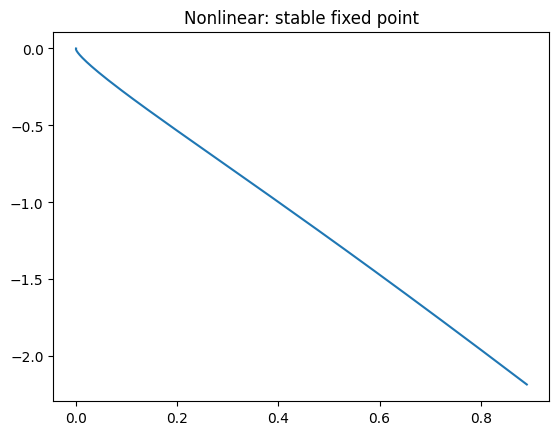

In [ ]:
rnn = nonlinear_RNN(2, tau=10, T_int=1000)
rnn.W.data *= 0.5

traj = rnn(torch.randn(1,2)).detach().numpy()

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.title("Nonlinear: stable fixed point")


**Example 6: Rich non-linear dynamics**

Text(0.5, 1.0, 'Nonlinear: complex trajectories')

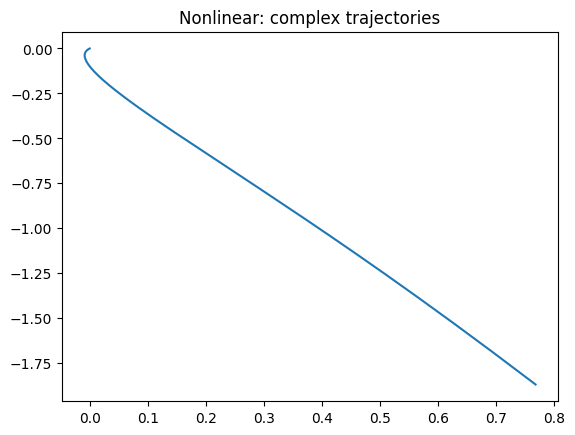

In [ ]:
rnn.W.data *= 2.0

traj = rnn(torch.randn(1,2)).detach().numpy()

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.title("Nonlinear: complex trajectories")

**Example 7: Chaos demo**

In [ ]:
#scale the evalues of the matrix J but a constant rho
def scale_spectral_radius(W, rho):
    eigvals = torch.linalg.eigvals(W)
    max_eig = torch.max(torch.abs(eigvals)).real
    return W * (rho / max_eig)

traj.shape (50, 10000)


Text(0.5, 1.0, 'Chaotic activity')

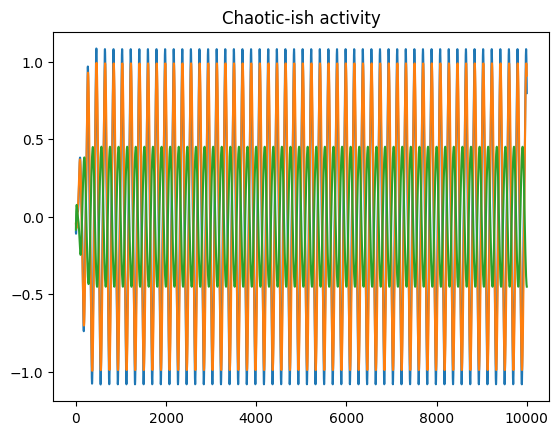

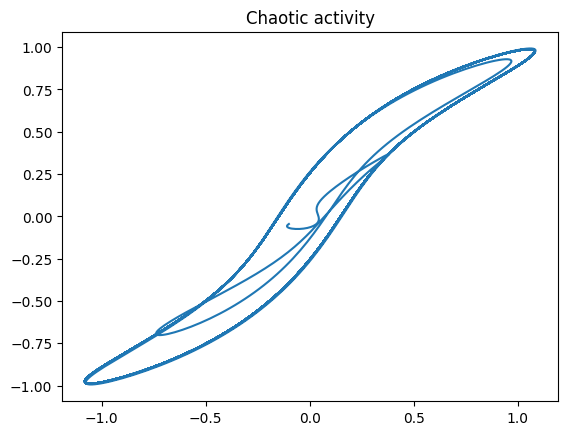

In [ ]:
N = 50
rnn = nonlinear_RNN(N, tau=10, T_int=10000)

rnn.W.data = scale_spectral_radius(rnn.W.data, rho=1.5)

h0 = 0.1*torch.randn(1,N)
traj = rnn(h0).detach().numpy()

print("traj.shape", traj.shape)

plt.figure()
plt.plot(traj[0,:])
plt.plot(traj[1,:])
plt.plot(traj[2,:])
plt.title("Chaotic-ish activity")

plt.figure()
plt.plot(traj[0,:], traj[1,:])
plt.title("Chaotic activity")
#run this cell multiple times to see different patterns

Along a chaotic trajectory, the discrete-time Jacobian at each point will usually have some eigenvalues with magnitude greater than 1 (expanding directions) and some less than 1 (contracting directions), with the exact spectrum changing over time.

**Why use chaotic RNNs at all?**

First, they resemble what the brain does, and even more amazing...

*Adding Input to a Chaotic RNN*

Chaotic RNNs are interesting because they can produce rich internal dynamics, which can be harnessed for computation. How the network responds depends on the strength of the input:


*   Very strong input

The external signal dominates the network dynamics.

The trajectory of the RNN mostly follows the input, and the internal chaos is suppressed.

Useful when you just want the network to track or transform a signal.

*   Moderate input

The input perturbs the network but does not completely dominate it.

The network exhibits rich, complex trajectories, mixing internal chaotic dynamics with input-driven structure.

This is the regime exploited in **reservoir computing / echo state networks**: a simple linear readout of the RNN activity can compute highly non-linear functions of the input.

Intuition: the chaos expands the “dimensionality” of the representation in the network. A linear readout can then combine these rich trajectories to approximate complicated input-output functions, without needing to train the recurrent weights themselves.


.

.

.

**Exercise (at home, if you're interested): Predict a Nonlinear Function Using a Chaotic RNN**


**Goal:** Demonstrate that a chaotic RNN can transform a simple input into **high-dimensional dynamics**, from which a **linear readout** can approximate a nonlinear function of the input.

---

### Steps

1. **Define a simple 1D input signal:**  

$$u(t) = \sin\Big(\frac{8 \pi t}{T}\Big), \quad t = 0,1,\dots,T-1$$


```python
T = 200
u = torch.sin(torch.linspace(0, 8*np.pi, T)).unsqueeze(1)  # shape (T, 1)
```

2. **Use a chaotic RNN with continuous dynamics:**

$$\frac{d\textbf{x}}{dt} = −\textbf{x} + \textbf{W} \cdot \tanh⁡(\textbf{x})$$

Here $\textbf{W}$ is a random weight matrix with large values to ensure chaotic dynamics.

Simulate the RNN response to the input \textbf{u}(t).

```python
rnn_output, _ = rnn(u)  # shape (T, hidden_size)
```

3. **Collect the RNN activity $\textbf{r}(t)$ over time as your reservoir states.**

Define a nonlinear target function of the input:

$$y_{\textrm{target}}(t)=\sin⁡(2\textbf{u}(t))+0.5 \textbf{u}^2(t)$$

4. **Train a linear readout to map the RNN activity to the target:**

$$y(t) = \textbf{r}(t)⋅\textbf{w}_{out} + b$$

```python
linear = nn.Linear(hidden_size, 1)
optimizer = torch.optim.Adam(linear.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
```

5. **Evaluate the performance:**

Plot $y_{\textrm{target}}(t)$ vs. $y(t)$.

Compare with a non-chaotic RNN (smaller W) to see how chaos expands the representational power.

.